In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv("Customer_Churn.csv")

In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.shape

(7043, 21)

In [6]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# EDA(Exploratory Data Analysis)

In [10]:
data.shape

(7043, 21)

In [11]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [12]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [14]:
def plot_distribution(df, column_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[column_name], kde = True)
    plt.title(f"Distribution of {column_name}")
    
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    plt.axvline(col_mean, color = "red", linestyle="--", label="Mean")
    plt.axvline(col_median, color = "blue", linestyle="--", label="Median")
    
    plt.legend()
    
    plt.subplot(1, 2, 2)
    sns.boxplot(y  = df[column_name])
    plt.title(f"Boxplot of {column_name}")
    plt.show()

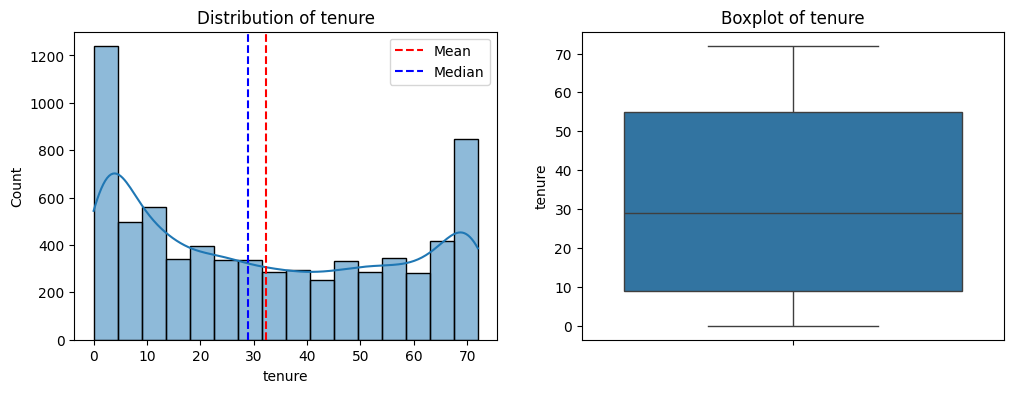

In [15]:
plot_distribution(data, "tenure")

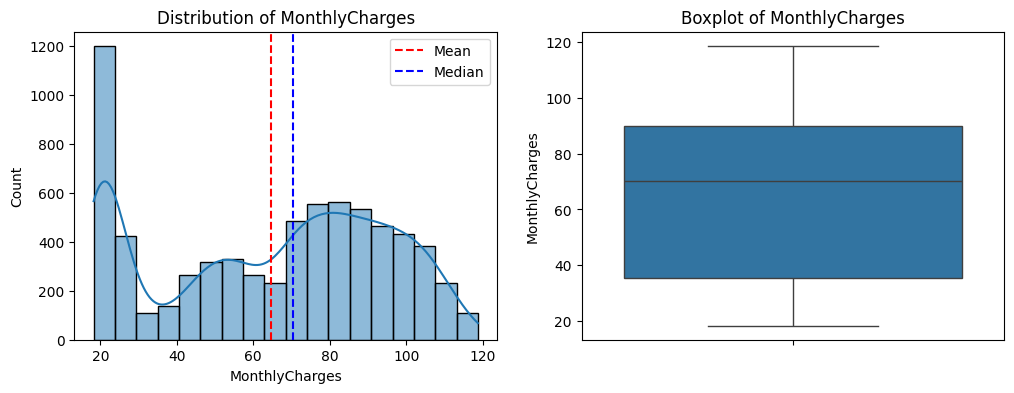

In [16]:
plot_distribution(data, "MonthlyCharges")

<Axes: >

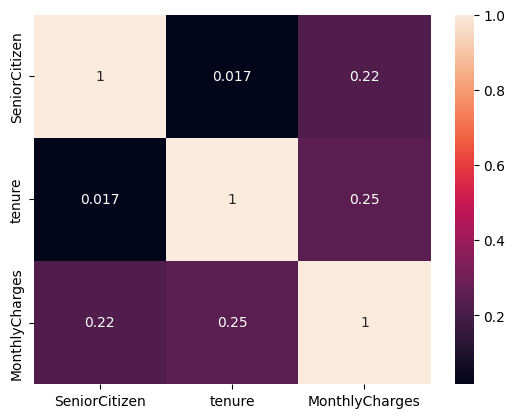

In [17]:
sns.heatmap(data.corr(numeric_only = True), annot = True)

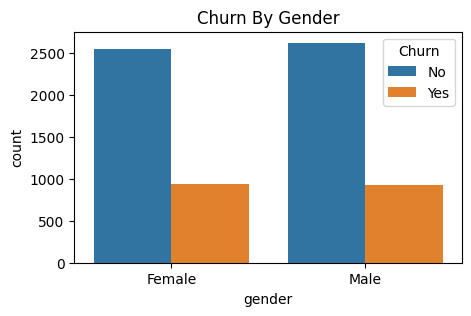

In [18]:
plt.figure(figsize = (5,3))
sns.countplot(x = "gender", data = data, hue = "Churn")
plt.title("Churn By Gender")
plt.show()

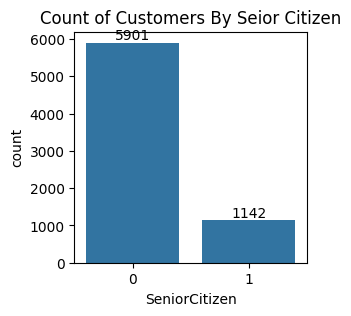

In [19]:
plt.figure(figsize = (3,3))
ax = sns.countplot(x = "SeniorCitizen",data = data)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers By Seior Citizen")
plt.show()

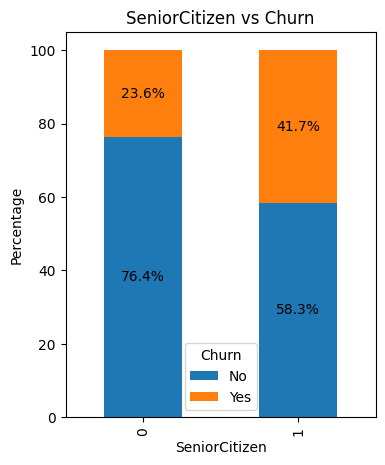

In [20]:
# Create crosstab
ct = pd.crosstab(data["SeniorCitizen"], data["Churn"])

# Convert into percentage
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = ct_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(4,5)
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.title("SeniorCitizen vs Churn")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

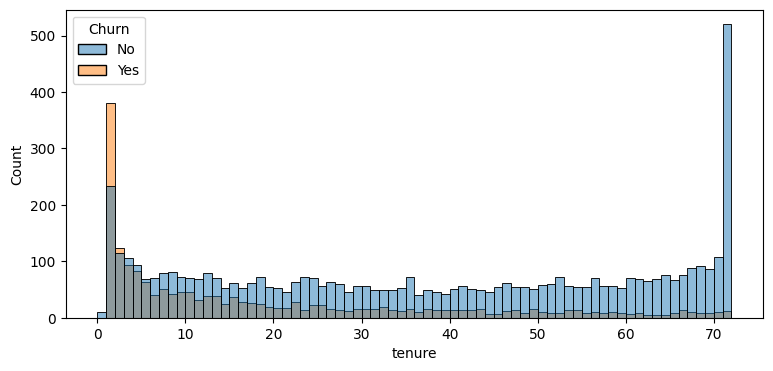

In [21]:
plt.figure(figsize = (9,4))
sns.histplot( x = "tenure", data=data , bins=72 , hue = "Churn")
plt.show()

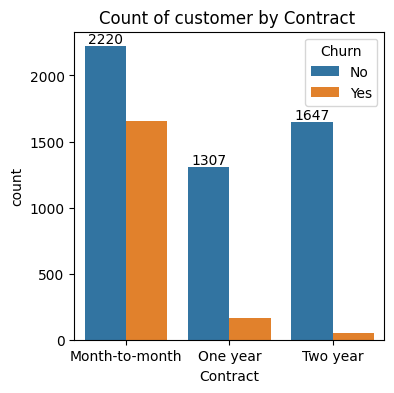

In [22]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract",data = data , hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of customer by Contract ")
plt.show()

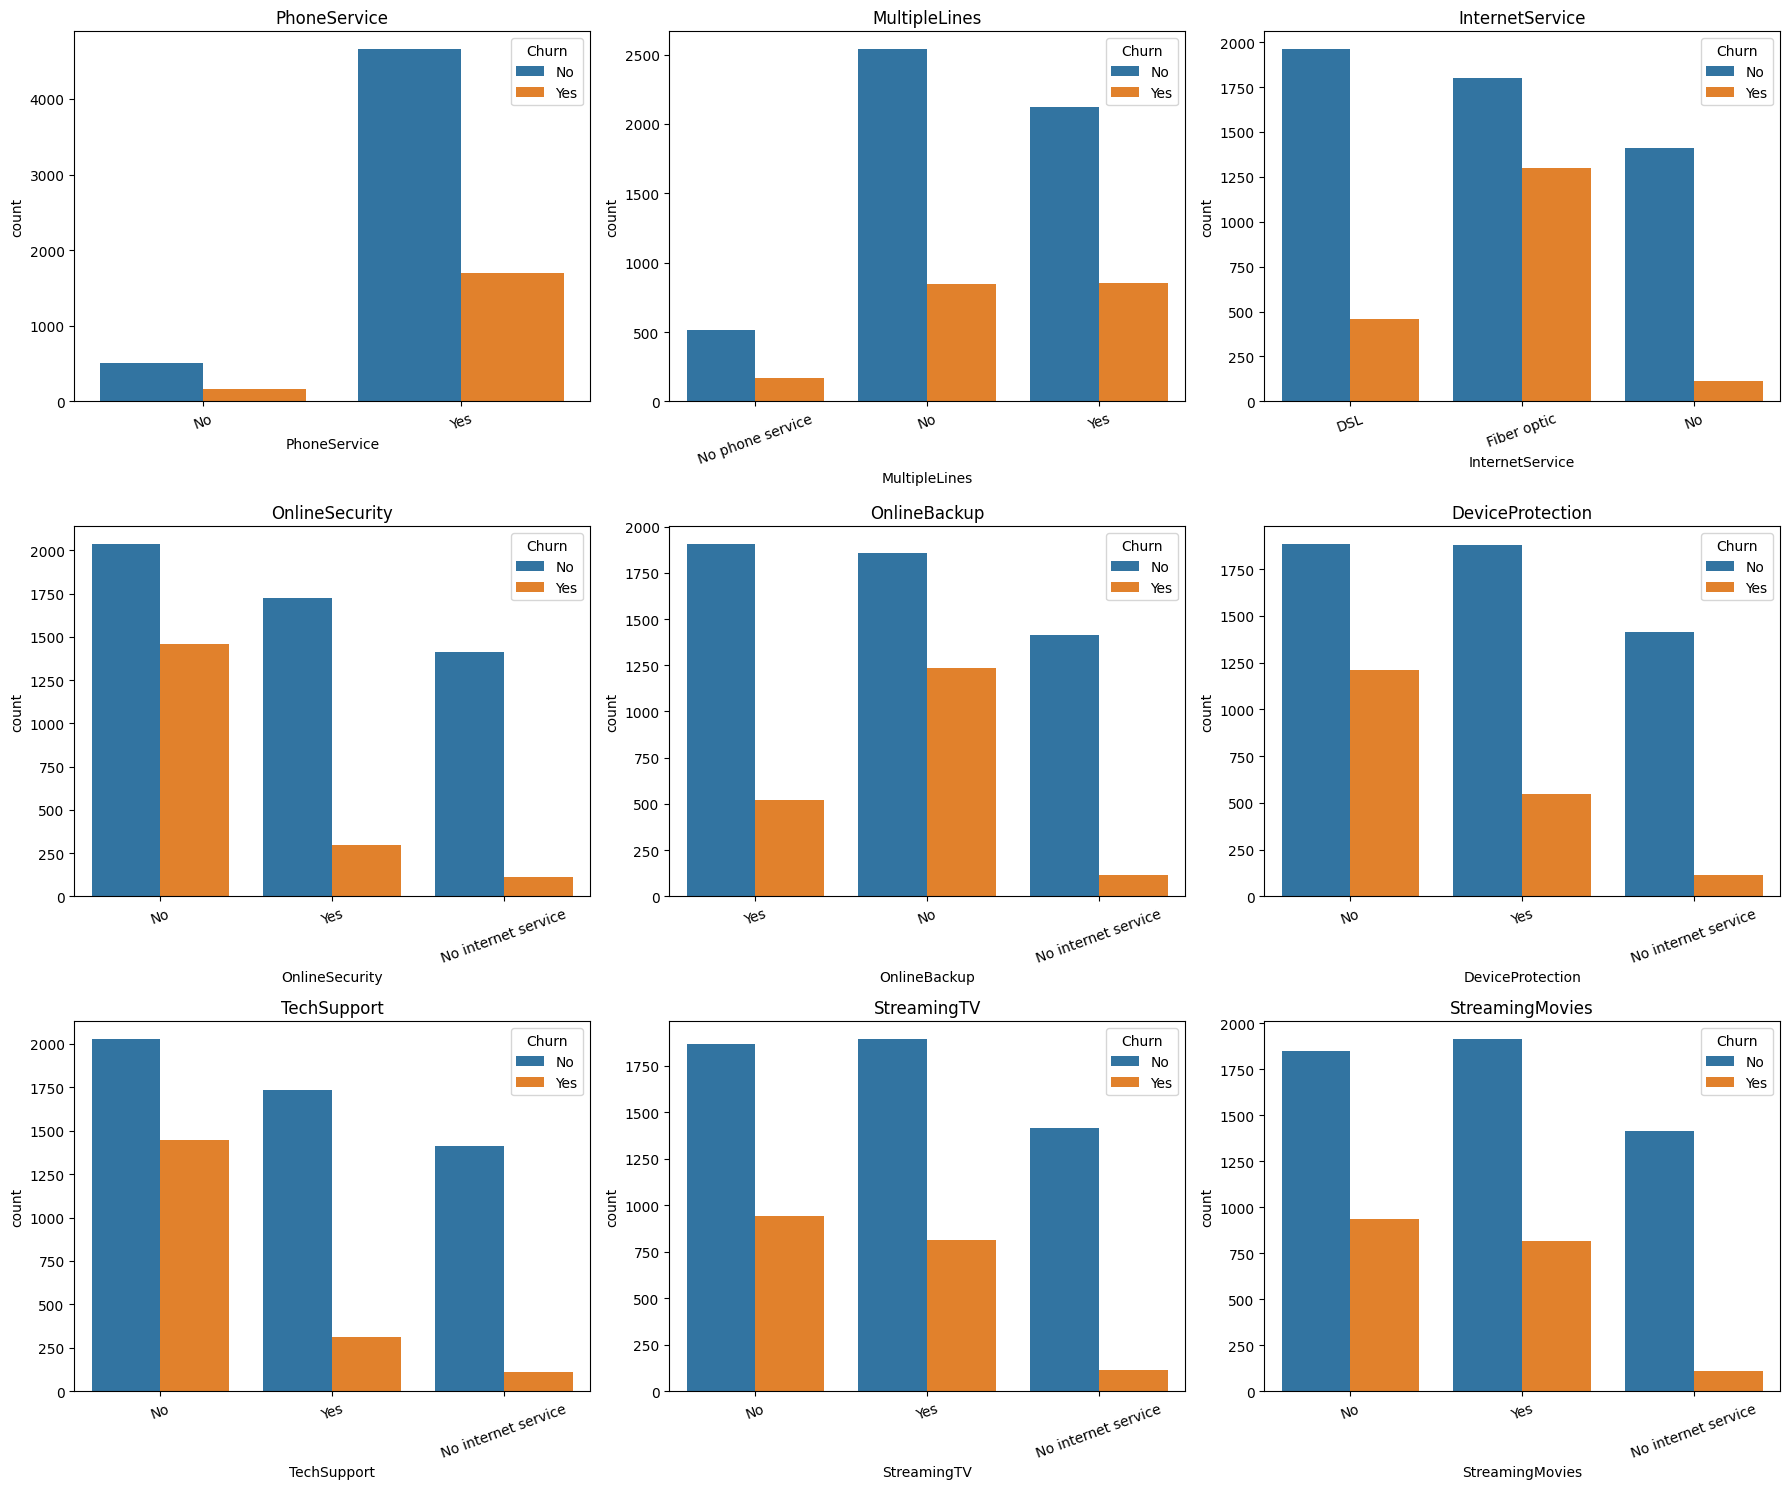

In [23]:
# List of columns
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplot layout
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Flatten axes for easy looping
axes = axes.flatten()

# Loop through columns and create countplots
for i, col in enumerate(cols):
    sns.countplot(x=data[col], ax=axes[i], hue=data["Churn"])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=20)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

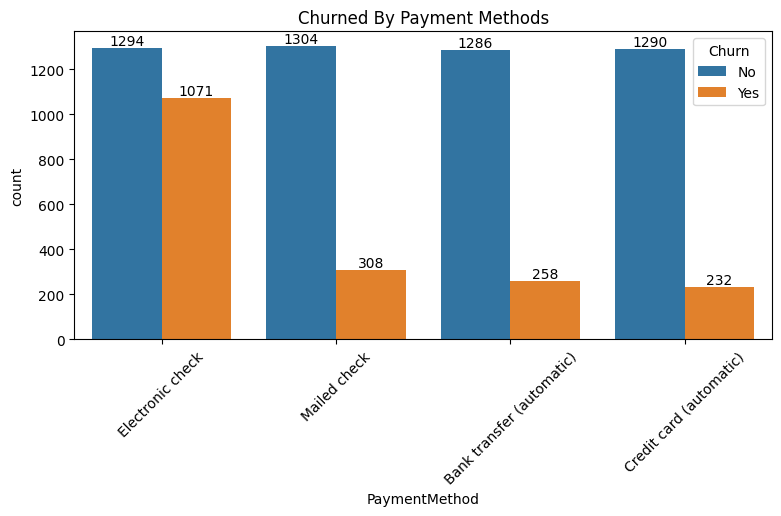

In [24]:
plt.figure(figsize = (9,4))
ax=sns.countplot(x = "PaymentMethod", data = data, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned By Payment Methods")
plt.xticks(rotation = 45)
plt.show()

# Data Cleanning

In [25]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [26]:
data["TotalCharges"]= data["TotalCharges"].replace(" ","0.0")
data["TotalCharges"]= data["TotalCharges"].astype("float")
data["tenure"] = data["tenure"].astype("float")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**converted 0 and 1 for senior citizen to yes/no to make it easier to understand**

In [27]:
def conv(value):
    if value == 1:
        return "Yes"

    else :
        return "No"
data["SeniorCitizen"] =  data["SeniorCitizen"].apply(conv)      

In [28]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
data.drop(columns = ["customerID"], inplace = True)

In [30]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

# Train-Test Split

In [31]:
X = data.drop(columns = ['Churn'])
y = data['Churn']

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Preprocessing: ColumnTransformer + Pipeline

In [34]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [35]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [36]:
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_cols = ["Partner", "Dependents", "PhoneService", "MultipleLines","InternetService", "OnlineSecurity", 
                    "OnlineBackup", 'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

#1. PipeLine For Numeric Columns
numeric_pipeline = Pipeline(steps = [
    ('impute',SimpleImputer(strategy = "median")),
    ('scale', StandardScaler())
    
])

#2. Pipeline For Categorical Columns
categorical_pipeline = Pipeline(steps = [
    ('impute', SimpleImputer(strategy= "most_frequent")),
    ('encode', OneHotEncoder(handle_unknown = 'ignore'))
])

preprocessor = ColumnTransformer(transformers = [
    ("numerical", numeric_pipeline, numerical_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

# Trying Multiple Algorithms

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Logistic Regression Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

# Predictions for Logistic Regression

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]


# Random Forest Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

# Predictions for Random Forest

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]


# Logistic Regression Results

print("========== Logistic Regression Results ==========")

print("Accuracy  :", accuracy_score(y_test, y_pred_lr))
print("Precision :", precision_score(y_test, y_pred_lr, pos_label="Yes"))
print("Recall    :", recall_score(y_test, y_pred_lr, pos_label="Yes"))
print("F1 Score  :", f1_score(y_test, y_pred_lr, pos_label="Yes"))


# Random Forest Results

print("\n========== Random Forest Results ==========")

print("Accuracy  :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf, pos_label="Yes"))
print("Recall    :", recall_score(y_test, y_pred_rf, pos_label="Yes"))
print("F1 Score  :", f1_score(y_test, y_pred_rf, pos_label="Yes"))

========== Logistic Regression Results ==========
Accuracy  : 0.7510648367250355
Precision : 0.526431718061674
Recall    : 0.8327526132404182
F1 Score  : 0.6450742240215924

========== Random Forest Results ==========
Accuracy  : 0.7671557027922385
Precision : 0.5628834355828221
Recall    : 0.6393728222996515
F1 Score  : 0.598694942903752


In [50]:
print(classification_report(y_test, y_pred_lr, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.92      0.72      0.81      1539
       Churn       0.53      0.83      0.65       574

    accuracy                           0.75      2113
   macro avg       0.72      0.78      0.73      2113
weighted avg       0.81      0.75      0.76      2113



In [51]:
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.84      1539
       Churn       0.56      0.64      0.60       574

    accuracy                           0.77      2113
   macro avg       0.71      0.73      0.72      2113
weighted avg       0.78      0.77      0.77      2113



In [52]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, pos_label="Yes"),
        precision_score(y_test, y_pred_rf, pos_label="Yes")
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, pos_label="Yes"),
        recall_score(y_test, y_pred_rf, pos_label="Yes")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, pos_label="Yes"),
        f1_score(y_test, y_pred_rf, pos_label="Yes")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.751065,0.526432,0.832753,0.645074
1,Random Forest,0.767156,0.562883,0.639373,0.598695


In [54]:
# Select the final model based on Churn Recall

best_model_name = results.loc[
    results["Recall"].idxmax(),
    "Model"
]

print(f"Best Model: {best_model_name}")
print("Selected based on highest Churn Recall.")

Best Model: Logistic Regression
Selected based on highest Churn Recall.


In [55]:
# Get transformed feature names

lr_preprocessor = logistic_model.named_steps["preprocessor"]
lr_model = logistic_model.named_steps["model"]

feature_names = lr_preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": abs(lr_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,numerical__tenure,1.221935
35,categorical__Contract_Two year,0.932236
33,categorical__Contract_Month-to-month,0.709019
2,numerical__TotalCharges,0.603702
13,categorical__InternetService_Fiber optic,0.571468
12,categorical__InternetService_DSL,0.523008
1,numerical__MonthlyCharges,0.486263
32,categorical__StreamingMovies_Yes,0.267638
36,categorical__PaperlessBilling_No,0.241824
40,categorical__PaymentMethod_Electronic check,0.232706


In [65]:
# Example customer prediction using final model

sample_customer = X_test.iloc[[0]]

prediction = logistic_model.predict(sample_customer)[0]
probability = logistic_model.predict_proba(sample_customer)[0][1]

if prediction == "Yes":
    print("Prediction: Customer is likely to CHURN")
else:
    print("Prediction: Customer is likely to STAY")

print(f"Churn Probability: {probability:.2%}")

Prediction: Customer is likely to CHURN
Churn Probability: 84.28%


In [58]:
# Model Performance Comparison

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr, pos_label="Yes"),
        precision_score(y_test, y_pred_rf, pos_label="Yes")
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr, pos_label="Yes"),
        recall_score(y_test, y_pred_rf, pos_label="Yes")
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr, pos_label="Yes"),
        f1_score(y_test, y_pred_rf, pos_label="Yes")
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.751065,0.526432,0.832753,0.645074
1,Random Forest,0.767156,0.562883,0.639373,0.598695


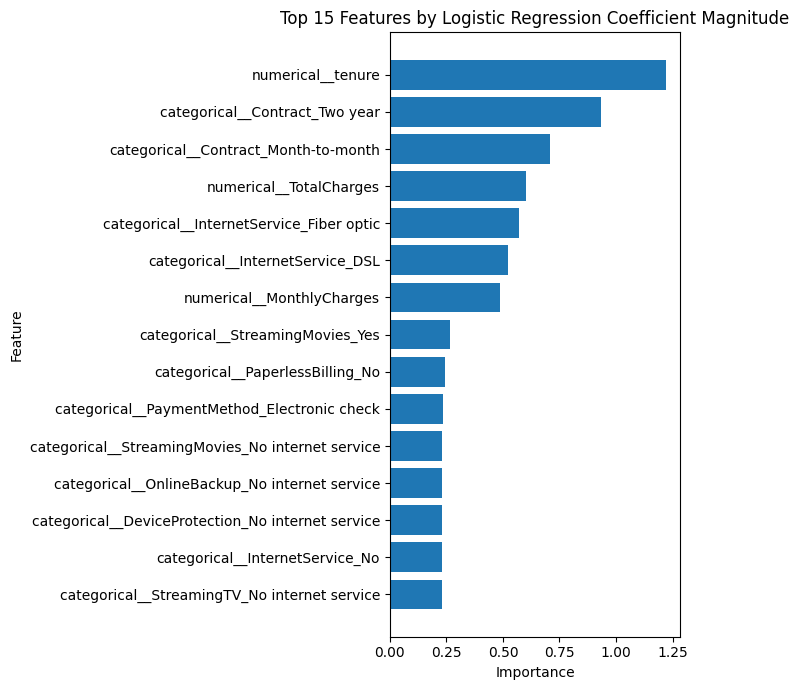

In [62]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(7, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features by Logistic Regression Coefficient Magnitude")
plt.tight_layout()
plt.show()

Task was destroyed but it is pending!
task: <Task pending name='Task-212' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-213' coro=<Kernel.shell_main() running at C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-213' coro=<Kernel.shell_main() running at C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


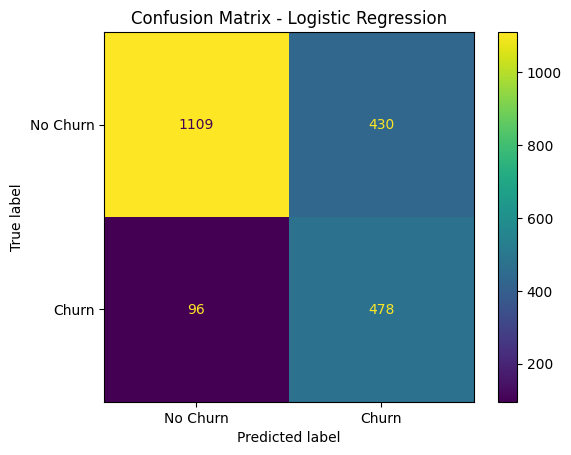

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["No", "Yes"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

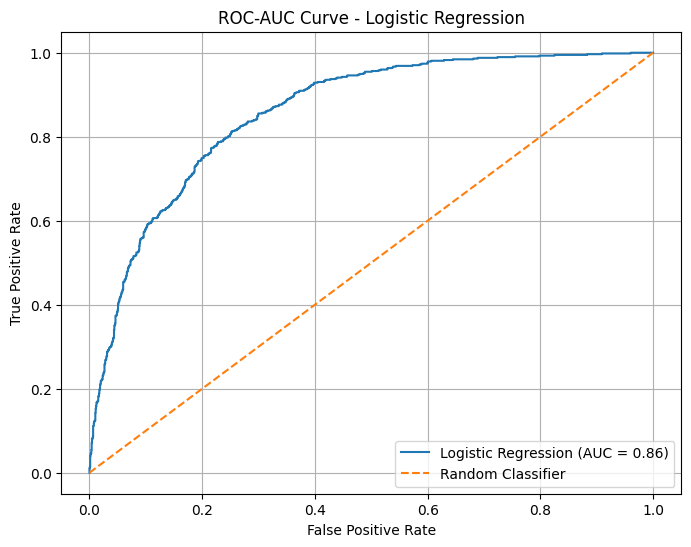

ROC-AUC Score: 85.84%


In [63]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_lr,
    pos_label="Yes"
)

# Calculate ROC-AUC Score
roc_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

# Random Classifier Line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.2%}")

In [64]:
import joblib

joblib.dump(logistic_model, "customer_churn_logistic_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.
